# Model Evaluation

This notebook is for evaluating the multi-output XGBoost carbon intensity forecasting model that is trained and saved from running "model_training.ipynb"

## Import Packages

In [80]:
import numpy as np
import pandas as pd
import pickle
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)

## Import All Data

In [81]:
# Import original dataset
data = pd.read_csv(
    "data/carbon_intensity_demand_solar_wind_2022-01-01_2023-01-01.csv",
    parse_dates=["from"],
    index_col=[0],
)

In [82]:
# Load the saved model
OUTPUT_DIR = "data/outputs/model"
reg = pickle.load(open(f"{OUTPUT_DIR}/xgb_regressor_carbon_intensity_forecast.pkl", "rb"))

# Load training data from file
X_train = pickle.load(open(f"{OUTPUT_DIR}/X_train.pkl", "rb"))
X_test = pickle.load(open(f"{OUTPUT_DIR}/X_test.pkl", "rb"))
Y_train = pickle.load(open(f"{OUTPUT_DIR}/Y_train.pkl", "rb"))
Y_test = pickle.load(open(f"{OUTPUT_DIR}/Y_test.pkl", "rb"))

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (11708, 864), X_test: (2927, 864)


## Inference Model and Get Forecast Predictions

In [83]:
Y_pred = reg.predict(X_test)
Y_actual = Y_test.values

print(f"Evaluation rows: {len(Y_pred)}")

Evaluation rows: 2927


## Statistical Error Comparison to National Grid (NESO) Forecast

In [84]:
mae = mean_absolute_error(Y_actual, Y_pred)
mse = mean_squared_error(Y_actual, Y_pred)
rmse = root_mean_squared_error(Y_actual, Y_pred)
r2 = r2_score(Y_actual, Y_pred)
mape = mean_absolute_percentage_error(Y_actual, Y_pred)

In [85]:
# https://medium.com/@bhatadithya54764118/day-10-evaluation-metrics-for-regression-mse-mae-rmse-r%C2%B2-score-0ffb39e3ea26

test_start = X_test.index.min()  # Test set start date
test_end = X_test.index.max() + pd.Timedelta(hours=24)  # Test set end date
test_data = data.loc[test_start:test_end].dropna(
    subset=["carbon_intensity_forecast", "carbon_intensity_actual"]
)  # Drop NaNs
# Define actual and forecast carbon intensity for National Grid model for error comparison
ng_actual = test_data["carbon_intensity_actual"]
ng_forecast = test_data["carbon_intensity_forecast"]
# Print statistical comparison of our model and National Grid model
metrics = pd.DataFrame(
    {
        "XGBoost model": {
            "MAE": round(mae, 3),
            "MSE": round(mse, 3),
            "RMSE": round(rmse, 3),
            "MAPE": round(mape, 3) * 100.0,
            "R²": round(r2, 3),
        },
        "National Grid": {
            "MAE": round(mean_absolute_error(ng_actual, ng_forecast), 3),
            "MSE": round(mean_squared_error(ng_actual, ng_forecast), 3),
            "RMSE": round(root_mean_squared_error(ng_actual, ng_forecast), 3),
            "R²": round(r2_score(ng_actual, ng_forecast), 3),
            "MAPE": round(mean_absolute_percentage_error(ng_actual, ng_forecast), 3) * 100.0,
        },
    }
)
print(metrics.to_string())

      XGBoost model  National Grid
MAE          17.054         10.837
MSE         505.841        233.470
RMSE         21.959         15.280
MAPE         11.500          7.900
R²            0.869          0.952


## Hours Ahead in Forecast Error

In [86]:
hours_ahead = np.arange(0.5, 24.5, 0.5)  # 30 min -> 24 hr forecast steps (x-axis) - horizon from T=0

mae_per_horizon = [mean_absolute_error(Y_actual[:, h], Y_pred[:, h]) for h in range(48)]  # MAE for rolling predictions

mape_per_horizon = [
    mean_absolute_percentage_error(Y_actual[:, h], Y_pred[:, h]) for h in range(48)
]  # MAE for rolling predictions

rmse_per_horizon = [
    root_mean_squared_error(Y_actual[:, h], Y_pred[:, h]) for h in range(48)
]  # MAE for rolling predictions

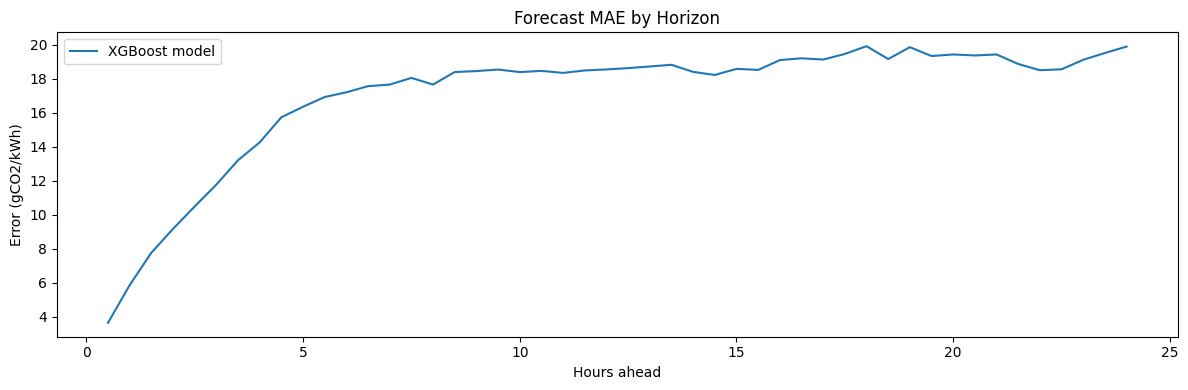

In [87]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hours_ahead, mae_per_horizon, label="XGBoost model")
ax.set_xlabel("Hours ahead")
ax.set_ylabel("Error (gCO2/kWh)")
ax.set_title("Forecast MAE by Horizon")
ax.legend()
plt.tight_layout()
plt.savefig("data/outputs/figures/forecast_MAE_by_horizon.png", dpi=200)

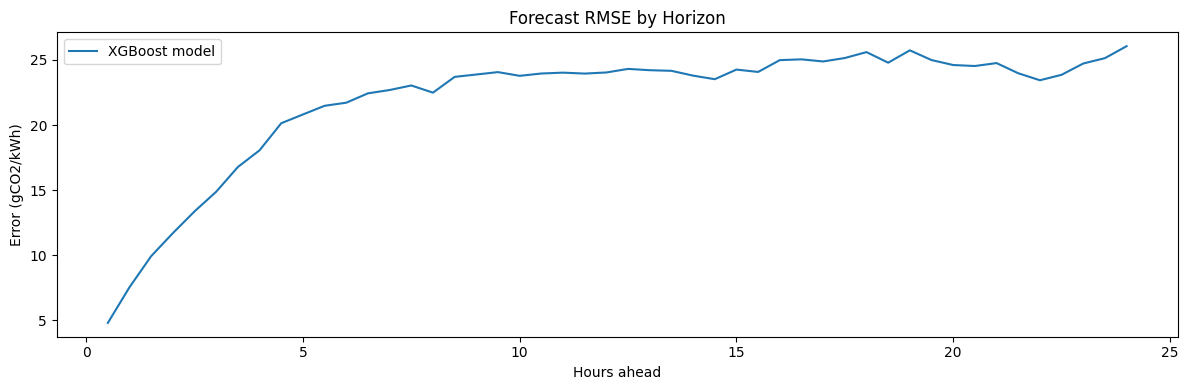

In [88]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hours_ahead, rmse_per_horizon, label="XGBoost model")
ax.set_xlabel("Hours ahead")
ax.set_ylabel("Error (gCO2/kWh)")
ax.set_title("Forecast RMSE by Horizon")
ax.legend()
plt.tight_layout()
plt.savefig("data/outputs/figures/forecast_RMSE_by_horizon.png", dpi=200)

## Feature Importance

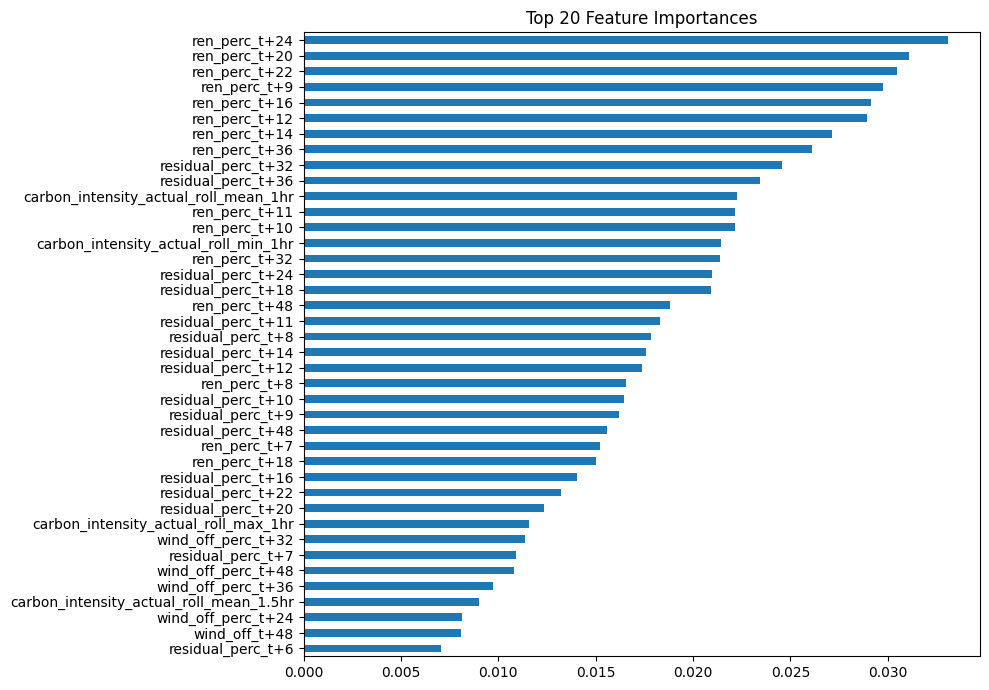

In [92]:
# Averaged feature importances across all 48 output horizon trees
feat_imp = pd.Series(reg.feature_importances_, index=X_train.columns)
feat_imp.nlargest(40).sort_values().plot(kind="barh", figsize=(10, 7), title="Top 20 Feature Importances")
plt.tight_layout()
plt.savefig("data/outputs/figures/model_important_features.png", dpi=150)

## Example Forecast Comparison Plots

In [90]:
feature_cols = list(X_train.columns)

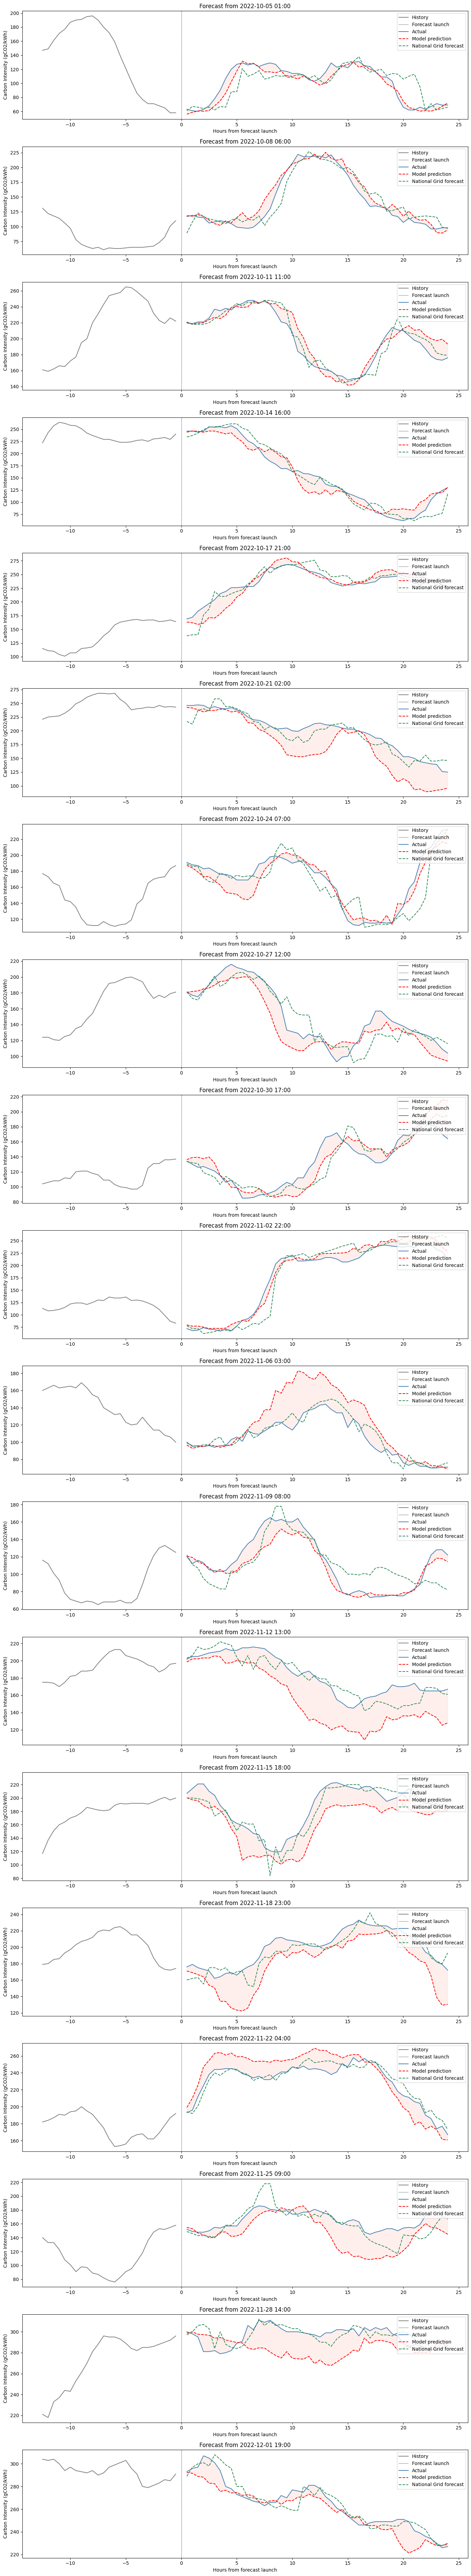

In [91]:
# Forecast window plots
n_examples = 19  # For plotting 19 examples of forecast predictions
step = len(X_test) // n_examples
start_indices = [i * step for i in range(n_examples)]

fig, axes = plt.subplots(n_examples, 1, figsize=(14, 4 * n_examples), sharex=False)

for ax, idx in zip(axes, start_indices):
    launch_time = X_test.index[idx]
    launch_loc = data.index.get_loc(launch_time)

    if launch_loc + 48 >= len(data):  # continue in loop once we hit 24-hr horizon
        continue

    # Multi-output- single predict call returns all 48 horizons
    row = X_test.loc[[launch_time]][feature_cols]
    forecast_48 = reg.predict(row)[0]
    actual_48 = data["carbon_intensity_actual"].iloc[launch_loc + 1 : launch_loc + 49].values
    ng_forecast_48 = data["carbon_intensity_forecast"].iloc[launch_loc + 1 : launch_loc + 49].values

    history_len = 24  # define timesteps before forecast window for previous trend
    history_start = max(0, launch_loc - history_len)
    history = data["carbon_intensity_actual"].iloc[history_start : launch_loc + 1].values

    history_x = np.arange(-len(history), 0) * 0.5
    forecast_x = np.arange(1, 49) * 0.5

    ax.plot(history_x, history, color="grey", lw=1.5, label="History")
    ax.axvline(0, color="black", linestyle=":", lw=1, label="Forecast launch")
    ax.plot(forecast_x, actual_48, color="steelblue", lw=1.5, label="Actual")
    ax.plot(
        forecast_x,
        forecast_48,
        color="red",
        lw=1.5,
        linestyle="--",
        label="Model prediction",
    )
    ax.plot(
        forecast_x,
        ng_forecast_48,
        color="seagreen",
        lw=1.5,
        linestyle="--",
        label="National Grid forecast",
    )
    ax.fill_between(forecast_x, actual_48, forecast_48, alpha=0.1, color="tomato")  # plot difference with fill

    ax.set_title(f'Forecast from {launch_time.strftime("%Y-%m-%d %H:%M")}')
    ax.set_xlabel("Hours from forecast launch")
    ax.set_ylabel("Carbon Intensity (gCO2/kWh)")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("data/outputs/figures/forecast_examples_comparison.png")
plt.show()